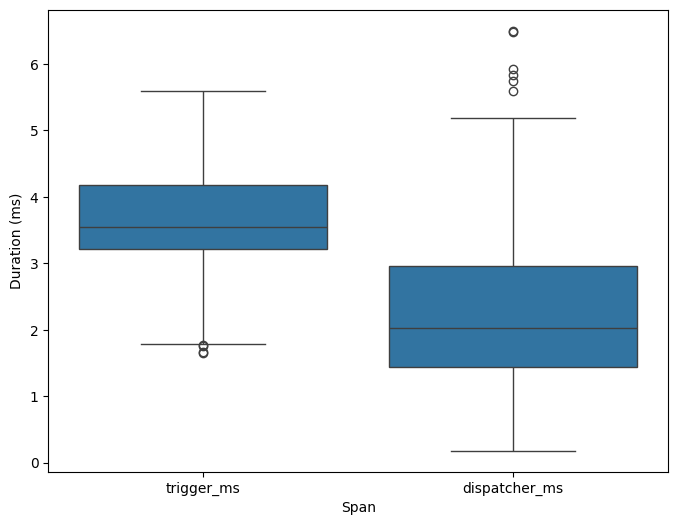

In [4]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Load JSON data
with open('3Site/new_traces.json') as f:
    data = json.load(f)

results = []

# Process each trace
for trace in data['data']:
    trace_id = trace['traceID']
    spans = trace['spans']

    # Check there are at least 7 spans to access indices 0 and 6
    if len(spans) >= 7:
        span1_us = spans[0]['duration']   # duration in microseconds
        span6_us = spans[6]['duration']
        total_us = span1_us + span6_us

        # Convert durations from microseconds to milliseconds
        results.append({
            'traceID': trace_id,
            'trigger_ms': span1_us / 1000,
            'dispatcher_ms': span6_us / 1000,
            'total_duration_ms': total_us / 1000
        })

# Create a pandas DataFrame from the results
df_3Site = pd.DataFrame(results)

def remove_outliers_iqr(df_3Site, col):
    Q1 = df_3Site[col].quantile(0.25)
    Q3 = df_3Site[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df_3Site[(df_3Site[col] >= lower_bound) & (df_3Site[col] <= upper_bound)]

# Remove outliers for each duration column independently
df_filtered_trigger = remove_outliers_iqr(df_3Site, 'trigger_ms')
df_filtered_dispatcher = remove_outliers_iqr(df_3Site, 'dispatcher_ms')
df_filtered_total = remove_outliers_iqr(df_3Site, 'total_duration_ms')

# Keep rows that are inside IQR range for all three columns
df_filtered = df_3Site[
    df_3Site.index.isin(df_filtered_trigger.index) & 
    df_3Site.index.isin(df_filtered_dispatcher.index) & 
    df_3Site.index.isin(df_filtered_total.index)
]

# Extract only traceID, trigger_ms and dispatcher_ms columns
df_show = df_filtered[['traceID', 'trigger_ms', 'dispatcher_ms']]

# Melt only the two columns for plotting
df_melted = df_filtered.melt(
    id_vars='traceID',
    value_vars=['trigger_ms', 'dispatcher_ms'],  # only two columns here
    var_name='Span', value_name='Duration_ms'
)

plt.figure(figsize=(8,6))
sns.boxplot(x='Span', y='Duration_ms', data=df_melted)

plt.ylabel('Duration (ms)')
plt.xlabel('Span')
plt.savefig("Boxplot of Trigger and Dispatcher Durations (ms) without IQR Outliers Balancin")  # Can also use .jpg, .pdf, .svg, etc.

plt.show()



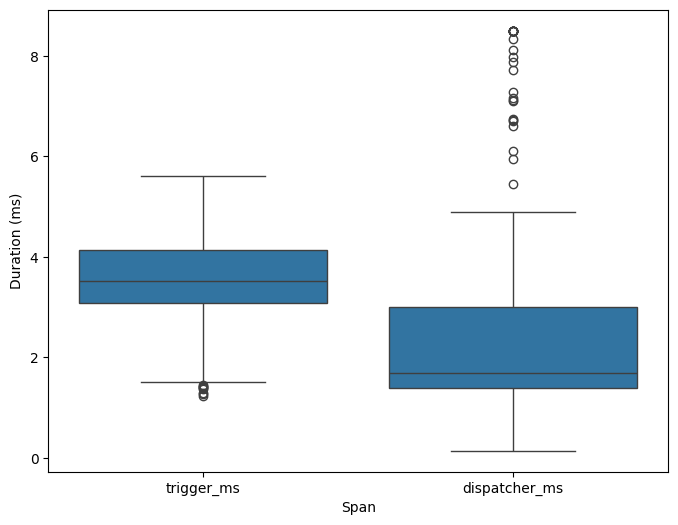

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import json
import pandas as pd

# Load JSON data
with open('1Site/new_traces.json') as f:
    data = json.load(f)

results = []

# Process each trace
for trace in data['data']:
    trace_id = trace['traceID']
    spans = trace['spans']

    # Check there are at least 7 spans to access indices 0 and 6
    if len(spans) >= 7:
        span1_us = spans[0]['duration']   # duration in microseconds
        span6_us = spans[6]['duration']
        total_us = span1_us + span6_us

        # Convert durations from microseconds to milliseconds
        results.append({
            'traceID': trace_id,
            'trigger_ms': span1_us / 1000,
            'dispatcher_ms': span6_us / 1000,
            'total_duration_ms': total_us / 1000
        })

# Create a pandas DataFrame from the results
df = pd.DataFrame(results)

# Print the DataFrame
df


# Calculate 95th percentile for each duration column
p95_span1 = np.percentile(df['trigger_ms'], 95)
p95_span6 = np.percentile(df['dispatcher_ms'], 95)
p95_total = np.percentile(df['total_duration_ms'], 95)

# Filter rows by clipping durations at 95th percentile
df_filtered = df.copy()
df_filtered['trigger_ms'] = np.minimum(df['trigger_ms'], p95_span1)
df_filtered['dispatcher_ms'] = np.minimum(df['dispatcher_ms'], p95_span6)
df_filtered['total_duration_ms'] = np.minimum(df['total_duration_ms'], p95_total)

# Melt filtered data for seaborn, excluding 'total_duration_ms'
df_melted = df_filtered.melt(id_vars='traceID', 
                             value_vars=['trigger_ms', 'dispatcher_ms'],  # exclude total_duration_ms here
                             var_name='Span', value_name='Duration_ms')

plt.figure(figsize=(8,6))
sns.boxplot(x='Span', y='Duration_ms', data=df_melted)

plt.ylabel('Duration (ms)')
plt.xlabel('Span')
plt.savefig("Boxplot of Span Durations (ms) Clipped at 95th Percentile NoBalancingX")  # Can also use .jpg, .pdf, .svg, etc.
plt.show()


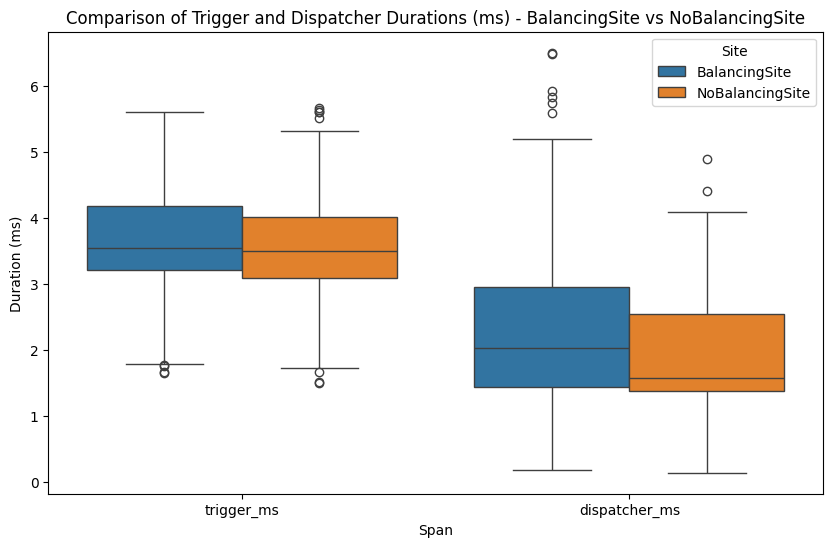

In [3]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def load_and_process_json(path):
    with open(path) as f:
        data = json.load(f)
    
    results = []
    for trace in data['data']:
        trace_id = trace['traceID']
        spans = trace['spans']
        if len(spans) >= 7:
            span1_us = spans[0]['duration']
            span6_us = spans[6]['duration']
            total_us = span1_us + span6_us
            
            results.append({
                'traceID': trace_id,
                'trigger_ms': span1_us / 1000,
                'dispatcher_ms': span6_us / 1000,
                'total_duration_ms': total_us / 1000
            })
    return pd.DataFrame(results)

def filter_outliers_iqr(df, cols):
    # Remove outliers in all columns using IQR method, but keep only rows passing all filters
    mask = pd.Series(True, index=df.index)
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        mask &= df[col].between(lower_bound, upper_bound)
    return df[mask]

# Load both datasets
df_3Site = load_and_process_json('3Site/new_traces.json')
df_1Site = load_and_process_json('1Site/new_traces.json')

# Add a column to identify dataset source
df_3Site['Site'] = 'BalancingSite'
df_1Site['Site'] = 'NoBalancingSite'

# Option 1: Use IQR filtering on both datasets for fair outlier removal
cols_to_filter = ['trigger_ms', 'dispatcher_ms', 'total_duration_ms']
df_3Site_filtered = filter_outliers_iqr(df_3Site, cols_to_filter)
df_1Site_filtered = filter_outliers_iqr(df_1Site, cols_to_filter)

# Combine both filtered DataFrames
df_combined = pd.concat([df_3Site_filtered, df_1Site_filtered], ignore_index=True)

# Melt for plotting: keep Site info, Span types and duration
df_melted = df_combined.melt(
    id_vars=['traceID', 'Site'],
    value_vars=['trigger_ms', 'dispatcher_ms'],
    var_name='Span',
    value_name='Duration_ms'
)

plt.figure(figsize=(10,6))
sns.boxplot(x='Span', y='Duration_ms', hue='Site', data=df_melted)

plt.title('Comparison of Trigger and Dispatcher Durations (ms) - BalancingSite vs NoBalancingSite')
plt.xlabel('Span')
plt.ylabel('Duration (ms)')
plt.legend(title='Site')

plt.savefig("Comparison of Trigger and Dispatcher Durations (ms) - BalancingSite vs NoBalancingSite")  # Can also use .jpg, .pdf, .svg, etc.
plt.show()


In [4]:
df_3Site.head()

,traceID,trigger_ms,dispatcher_ms,total_duration_ms,Site
0,ef8dc539b86c2afbb4d8f8e28c21fe07,3.866,1376.293,1380.159,BalancingSite
1,4987d9295103e8d7f745f88cea4a53af,2.391,1449.871,1452.262,BalancingSite
2,fe66cb6fb2e8f91eeb4b5f0e60bbae22,1.564,1004.257,1005.821,BalancingSite
3,006816f9a68ff5348c1f1f714c6a34e5,2.021,1018.789,1020.810,BalancingSite
4,9cfcb96b75f091d1b2bf7392b63557dc,1.954,1000.054,1002.008,BalancingSite


In [5]:
df_1Site.head()

,traceID,trigger_ms,dispatcher_ms,total_duration_ms,Site
0,ec06578b19b649abe6d8c1b53a6a912d,2.847,2.810,5.657,NoBalancingSite
1,16c3ee5c3482c5ba1bf75cc6403bc41c,2.875,3.521,6.396,NoBalancingSite
2,56eec63a6e9d47a5a1f561dda089fba0,4.639,1.699,6.338,NoBalancingSite
3,e155c88aeafcbfbd75bd068c13c5c058,3.006,1.574,4.580,NoBalancingSite
4,cbdb203ed7cf7f6a76118f085717e9fd,3.439,2.429,5.868,NoBalancingSite
